# Common Libraries

In [1]:
import os, sys, shutil
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from ipywidgets import interact
import matplotlib.pyplot as plt

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Paths

In [2]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/scaled_model_cvt3_mocap.xml"
qpos_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/IK_files/trial1_IK_qpos.csv"

# Model

In [3]:
model_gravity = mujoco.MjModel.from_xml_path(model_path)
model_gravity.opt.gravity = [-9.81, 0, 0]
model_gravity.vis.scale.framewidth = 0.05
model_gravity.vis.scale.framelength = 1
mj_data_gravity = mujoco.MjData(model_gravity)

joint_names = [mujoco.mj_id2name(model_gravity, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model_gravity.njnt)]
n_joints = len(joint_names)

model_noGravity = mujoco.MjModel.from_xml_path(model_path)
model_noGravity.opt.gravity = [0, 0, 0]
model_noGravity.vis.scale.framewidth = 0.05
model_noGravity.vis.scale.framelength = 1
mj_data_noGravity = mujoco.MjData(model_noGravity)

# Data

In [12]:
qpos_df = pd.read_csv(qpos_path, index_col = [0]).drop("times", axis = 1)

shoulder_elv_i = joint_names.index("shoulder_elv")
joint_angles = np.zeros(len(joint_names))
joint_angles[shoulder_elv_i] = 0.9

initial_pose = qpos_df.iloc[0] # qpos_df.iloc[0] joint_angles

# Scene

In [13]:
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

# Set initial pose

In [14]:
mj_data_gravity.qpos = initial_pose
mujoco.mj_forward(model_gravity, mj_data_gravity)

mj_data_noGravity.qpos = initial_pose
mujoco.mj_forward(model_noGravity, mj_data_noGravity)

# Render

In [15]:
gravity_renderer = mujoco.Renderer(model_gravity, height=400, width=600)
noGravity_renderer = mujoco.Renderer(model_noGravity, height=400, width=600)

# Simulation

In [16]:
n_sim = int(1 / model_gravity.opt.timestep) # 1s simulation

gravity_pixels = np.zeros((n_sim, gravity_renderer.height, gravity_renderer.width, 3), dtype = np.uint8)
noGravity_pixels = np.zeros((n_sim, noGravity_renderer.height, noGravity_renderer.width, 3), dtype = np.uint8)

qpos_gravity_list = np.zeros((n_sim, n_joints))
qpos_noGravity_list = np.zeros((n_sim, n_joints))

In [17]:
for sim_i in range(n_sim):
    # Gravity
    mujoco.mj_step(model_gravity, mj_data_gravity)
    qpos_gravity_list[sim_i] = mj_data_gravity.qpos.copy()
    gravity_renderer.update_scene(mj_data_gravity, camera = camera, scene_option = scene_option)
    gravity_pixels[sim_i] = gravity_renderer.render()

    # Non gravity
    mujoco.mj_step(model_noGravity, mj_data_noGravity)
    qpos_noGravity_list[sim_i] = mj_data_noGravity.qpos.copy()
    noGravity_renderer.update_scene(mj_data_noGravity, camera = camera, scene_option = scene_option)
    noGravity_pixels[sim_i] = noGravity_renderer.render()

In [18]:
def show_frame(frame_i = 0):
    fig, axes = plt.subplots(1, 2)
    fig.set_figwidth(14)
    fig.set_figheight(6)
    
    axes[0].imshow(gravity_pixels[frame_i])
    axes[1].imshow(noGravity_pixels[frame_i])
    axes[0].set_title(f"Gravity Frame: {frame_i}")
    axes[1].set_title(f"noGravity Frame: {frame_i}")
    axes[0].axis("off")
    axes[1].axis("off")
    
interact(show_frame, frame_i = (0, len(gravity_pixels) - 1))

interactive(children=(IntSlider(value=0, description='frame_i', max=29), Output()), _dom_classes=('widget-inte…

<function __main__.show_frame(frame_i=0)>

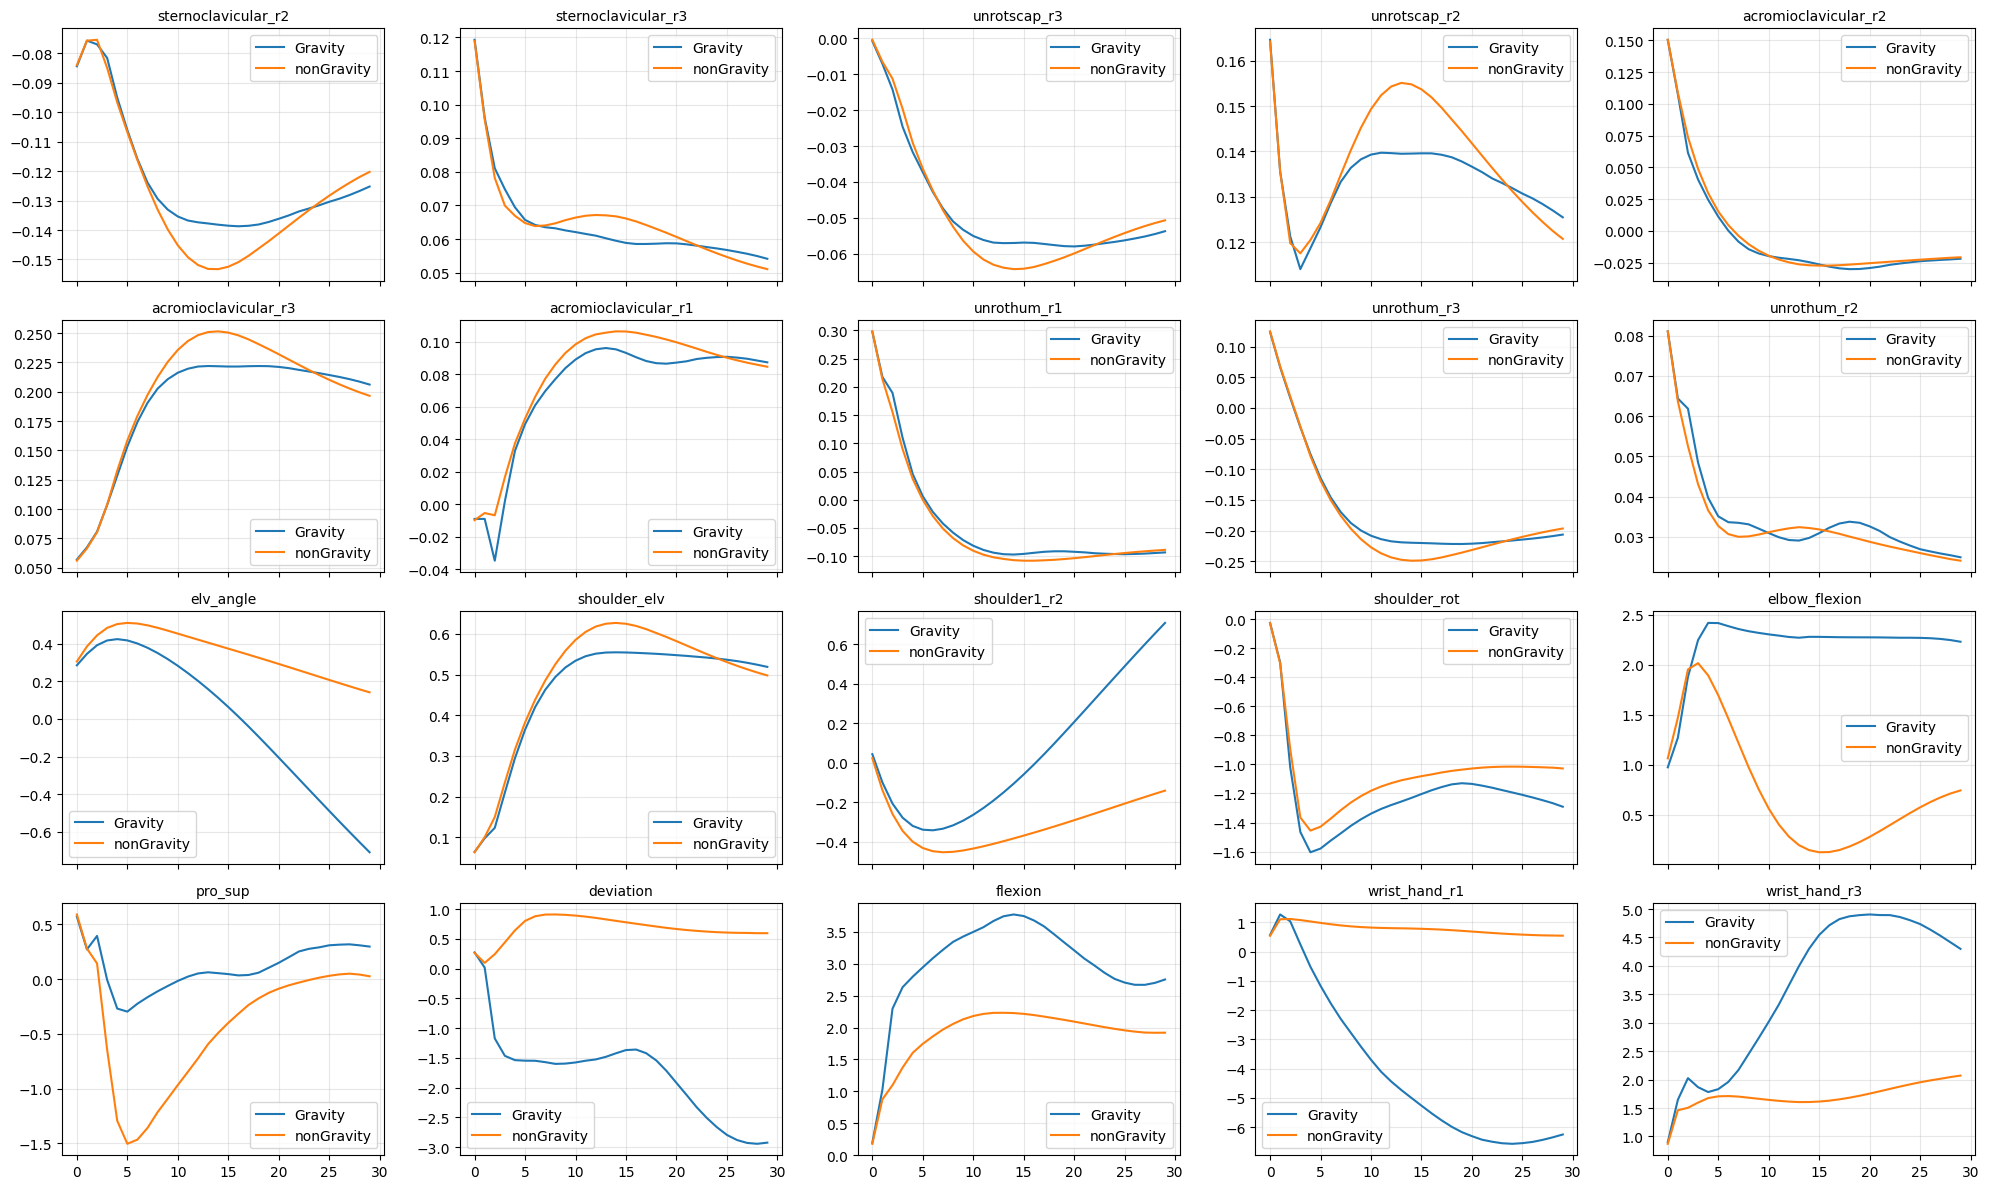

In [19]:
n_joint = len(joint_names)
n_cols = 5
n_rows = (n_joint + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()

for i, joint_name in enumerate(joint_names):
    ax = axes[i]
    ax.plot(qpos_gravity_list[:, i], lw=1.5, label = "Gravity")
    ax.plot(qpos_noGravity_list[:, i], lw=1.5, label = "nonGravity")
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend()
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()